# IRIS UV mini-spectrometer: all segment spectra

This notebook loads `IRVISUV_0.h5` for a selected GOLEM shot and plots wavelength vs intensity for **all time segments**.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from golem_data_loader import GolemDataLoader

In [ ]:
shot_number = 50150  # set your shot number here

print(f"Loading shot {shot_number}...")
loader = GolemDataLoader(shot_number=shot_number)
mini_data = loader.load_minispectrometer_h5(h5_filename="IRVISUV_0.h5", apply_sensitivity_correction=False)
print("Mini-spectrometer data loaded.")

wavelengths = np.asarray(mini_data.wavelengths)
spectra = np.asarray(mini_data.spectra)

if spectra.ndim != 2:
    raise ValueError(f"Expected 2D spectra array [segment, wavelength], got shape {spectra.shape}")

n_segments, n_wavelengths = spectra.shape
print(f"Shot {shot_number}")
print(f"Segments: {n_segments}")
print(f"Wavelength points per segment: {n_wavelengths}")
print(f"Wavelength range: {wavelengths.min():.2f} - {wavelengths.max():.2f} nm")

2026-02-26 17:28:43,221 - golem_data_loader.golem_data_loader - INFO - Successfully loaded plasma start time from http://golem.fjfi.cvut.cz/shots/50150/Diagnostics/PlasmaDetection/Results/t_plasma_start


Loading shot 50150...


2026-02-26 17:28:43,318 - golem_data_loader.golem_data_loader - INFO - Successfully loaded plasma end time from http://golem.fjfi.cvut.cz/shots/50150/Diagnostics/PlasmaDetection/Results/t_plasma_end
2026-02-26 17:28:43,328 - golem_data_loader.golem_data_loader - INFO - Loaded plasma timing: 2.32 - 21.43 ms
2026-02-26 17:28:43,329 - golem_data_loader.golem_data_loader - INFO - Downloading H5 file to C:\Users\stepa\AppData\Local\Temp\tmpk4_0fb_r.h5
2026-02-26 17:28:43,455 - golem_data_loader.golem_data_loader - INFO - Successfully loaded mini-spectrometer H5 file from http://golem.fjfi.cvut.cz/shots/50150/Diagnostics/MiniSpectrometer/DAS_raw_data_dir/IRVISUV_0.h5
2026-02-26 17:28:43,457 - golem_data_loader.golem_data_loader - INFO - Successfully downloaded H5 file (90576 bytes)
2026-02-26 17:28:43,473 - golem_data_loader.golem_data_loader - INFO - Loaded spectra: shape=(17, 2048), wavelengths: shape=(2047,)
2026-02-26 17:28:43,477 - golem_data_loader.golem_data_loader - WARNING - Mini-sp

Mini-spectrometer data loaded.
Shot 50150
Segments: 17
Wavelength points per segment: 2047
Wavelength range: 188.11 - 1108.53 nm


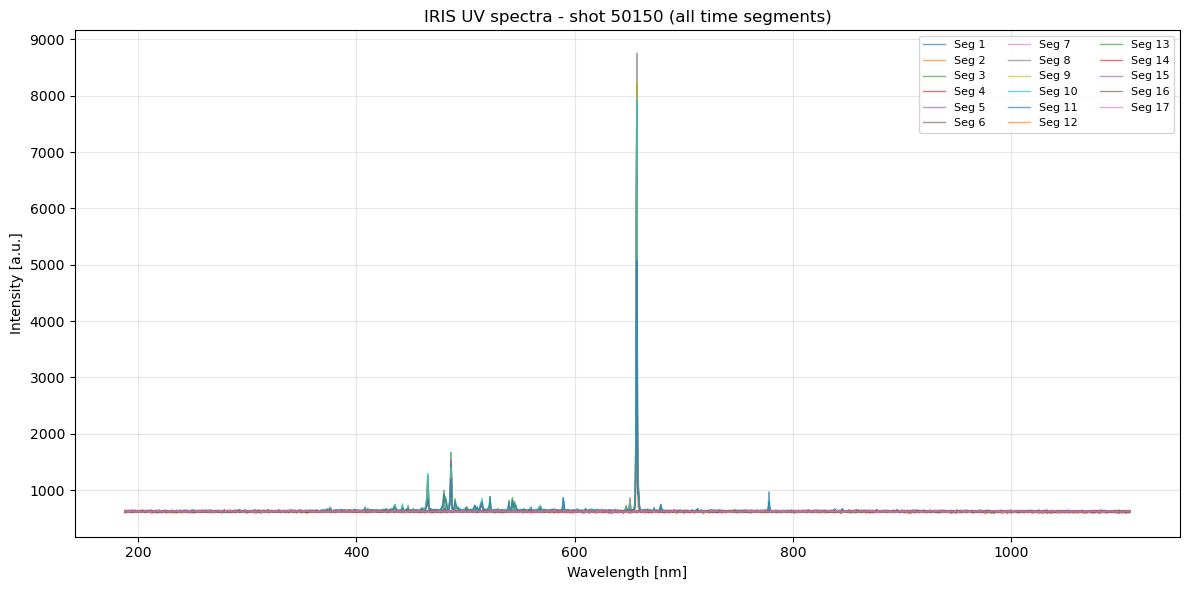

In [7]:
# Plot 1: all segments overlaid in one figure
fig, ax = plt.subplots(figsize=(12, 6))

for i in range(n_segments):
    label = f"Seg {i+1}" if n_segments <= 25 else None
    ax.plot(wavelengths, spectra[i], linewidth=1.0, alpha=0.65, label=label)

ax.set_title(f"IRIS UV spectra - shot {shot_number} (all time segments)")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Intensity [a.u.]")
ax.grid(True, alpha=0.3)
if n_segments <= 25:
    ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

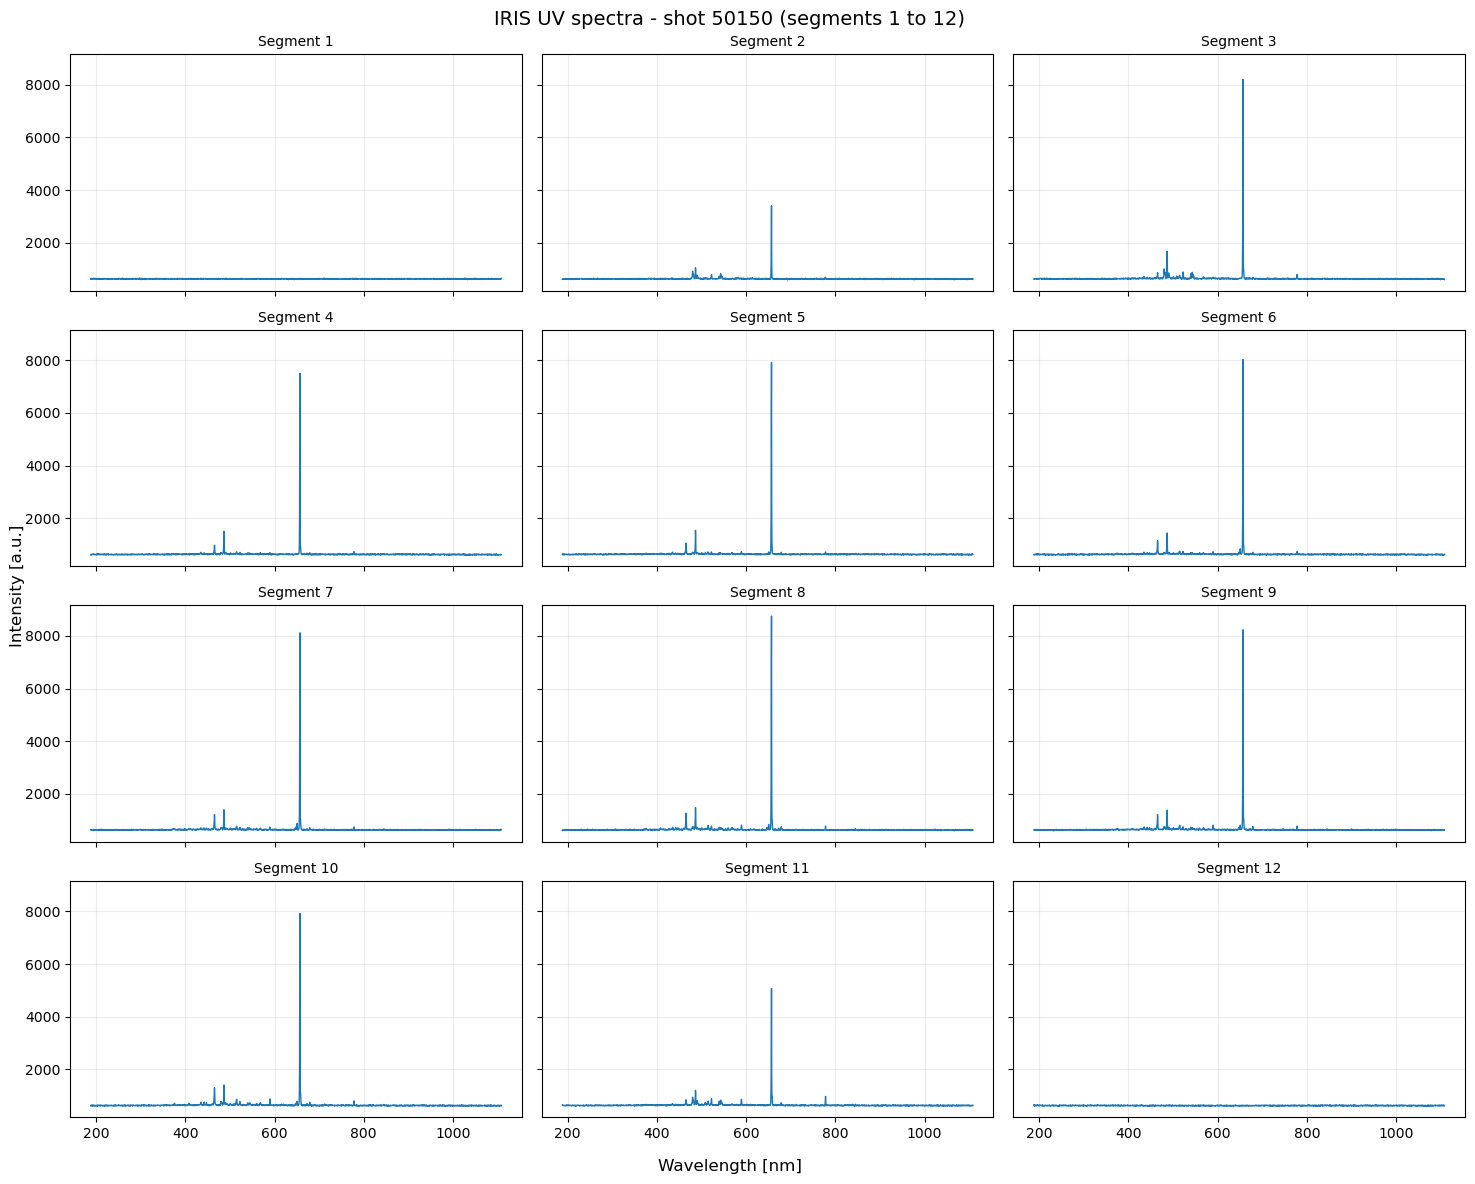

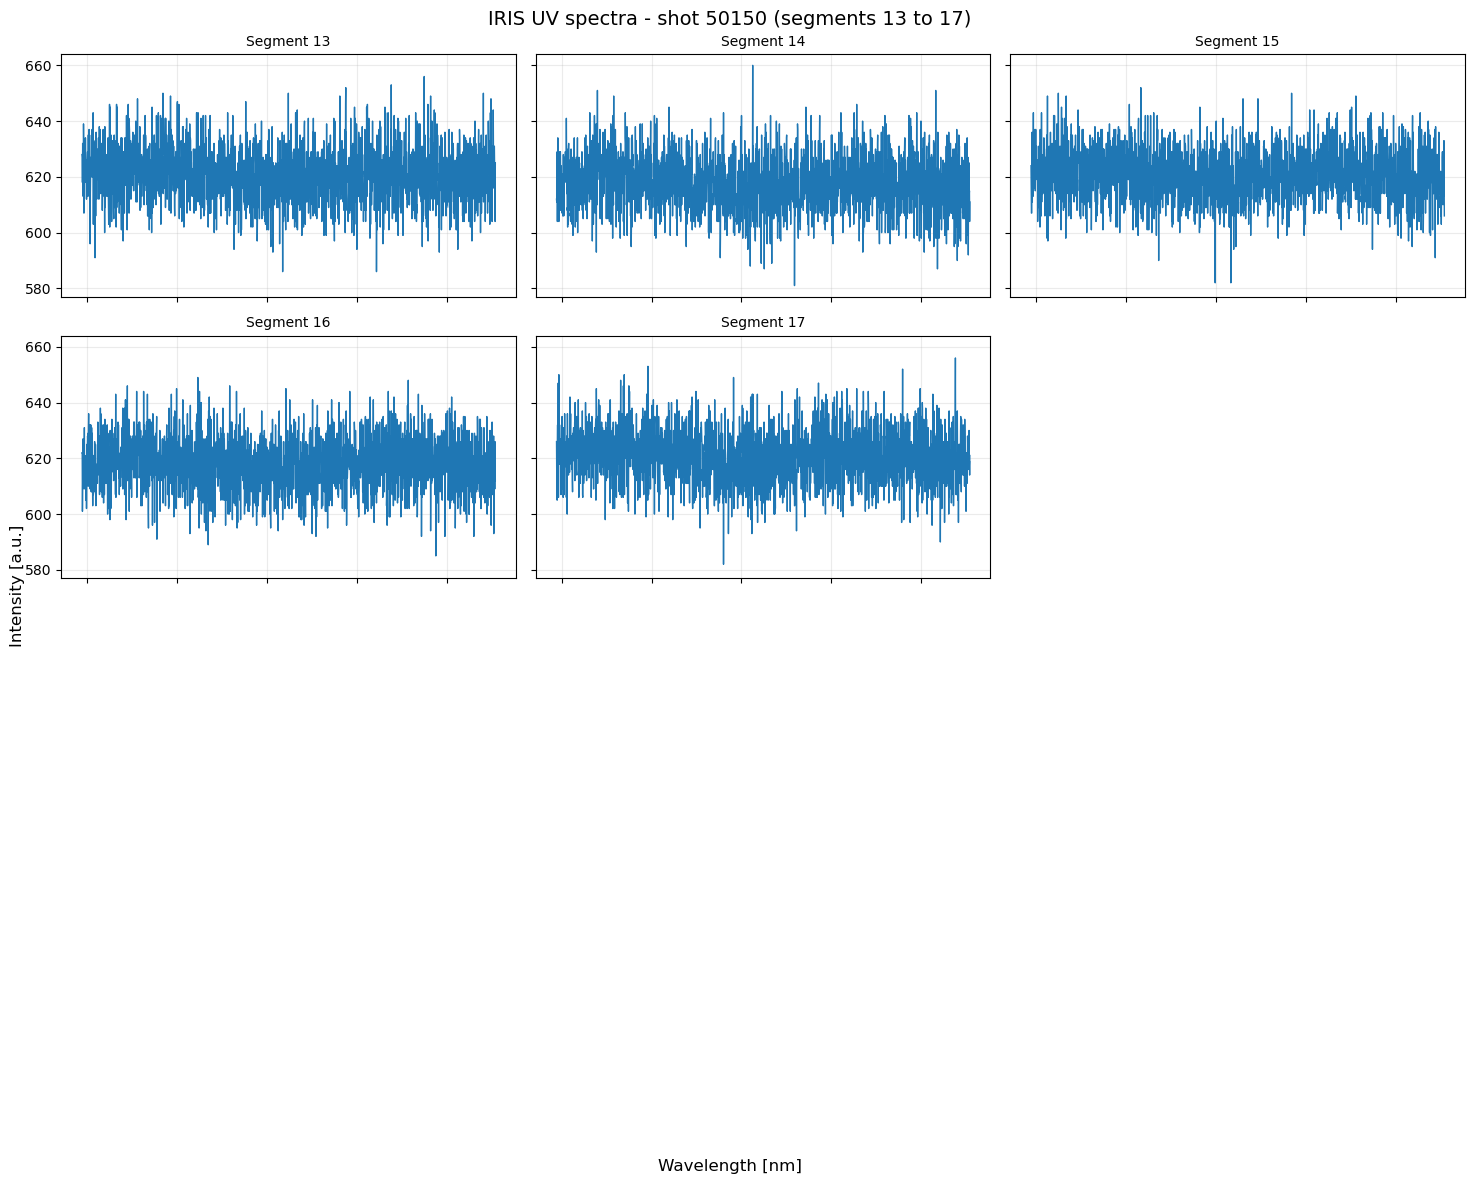

In [8]:
# Plot 2: each segment as its own subplot (paged)
plots_per_page = 12
rows, cols = 4, 3

for start in range(0, n_segments, plots_per_page):
    end = min(start + plots_per_page, n_segments)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 12), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax_i, seg_i in enumerate(range(start, end)):
        ax = axes[ax_i]
        ax.plot(wavelengths, spectra[seg_i], color="tab:blue", linewidth=1.0)
        ax.set_title(f"Segment {seg_i + 1}", fontsize=10)
        ax.grid(True, alpha=0.25)

    for ax_i in range(end - start, plots_per_page):
        axes[ax_i].axis("off")

    fig.suptitle(
        f"IRIS UV spectra - shot {shot_number} (segments {start + 1} to {end})",
        fontsize=14
    )
    fig.supxlabel("Wavelength [nm]")
    fig.supylabel("Intensity [a.u.]")
    plt.tight_layout()
    plt.show()